### What goes into Notebook 01:
* stratified train/validation split from the training set only
* first XGBoost multiclass run on 34-class
* evaluate with accuracy, weighted F1, macro F1, and per-class report
* save:
  * label encoder
  * model
  * feature column list
  * validation metrics
* only after that, run once on the merged holdout test set

### A good practical starting point for XGBoost is:
* `objective="multi:softprob"`
* `eval_metric="mlogloss"`
* `tree_method="hist"`
* `device="cuda"`
* `n_estimators` around 300 to 600
* `max_depth` around 6 to 10
* `learning_rate` around 0.05 to 0.1
* `subsample` around 0.8
* `colsample_bytree` around 0.8

Then we tune from there.

### Cell 1 -- Imports

In [1]:
from pathlib import Path
from collections import defaultdict
import json
import random
import re

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier
from xgboost.core import XGBoostError

### Cell 2 -- Config

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

TRAIN_MANIFEST_PATH = Path("artifacts/train_manifest.csv")
MODEL_DIR = Path("artifacts/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "label_8"
MAX_ROWS_PER_CLASS = 50_000
CHUNKSIZE = 250_000
VAL_SIZE = 0.20
XGB_DEVICE = "cuda"

FEATURE_COLUMNS = [
    "Header_Length",
    "Protocol Type",
    "Time_To_Live",
    "Rate",
    "fin_flag_number",
    "syn_flag_number",
    "rst_flag_number",
    "psh_flag_number",
    "ack_flag_number",
    "ece_flag_number",
    "cwr_flag_number",
    "ack_count",
    "syn_count",
    "fin_count",
    "rst_count",
    "HTTP",
    "HTTPS",
    "DNS",
    "Telnet",
    "SMTP",
    "SSH",
    "IRC",
    "TCP",
    "UDP",
    "DHCP",
    "ARP",
    "ICMP",
    "IGMP",
    "IPv",
    "LLC",
    "Tot sum",
    "Min",
    "Max",
    "AVG",
    "Std",
    "Tot size",
    "IAT",
    "Number",
    "Variance",
]

### Cell 3 --- Feature List and Helpers

In [3]:
train_manifest = pd.read_csv(TRAIN_MANIFEST_PATH)

class_names = sorted(train_manifest[TARGET_COL].dropna().unique())
label_to_id = {label: i for i, label in enumerate(class_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 8
['BENIGN', 'BRUTEFORCE', 'DDOS', 'DOS', 'MIRAI', 'RECON', 'SPOOFING', 'WEB']


### Cell 4 -- Balanced Row Sampler from Training Files

In [4]:
def sample_training_rows(
    manifest_df,
    feature_columns,
    target_col=TARGET_COL,
    max_rows_per_class=MAX_ROWS_PER_CLASS,
    chunksize=CHUNKSIZE,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    counters = defaultdict(int)
    parts = []

    shuffled = manifest_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    for row in shuffled.itertuples(index=False):
        label = getattr(row, target_col)

        if pd.isna(label):
            continue

        remaining = max_rows_per_class - counters[label]
        if remaining <= 0:
            continue

        path = Path(row.path)

        for chunk in pd.read_csv(path, usecols=feature_columns, chunksize=chunksize):
            for col in feature_columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

            chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna()

            if len(chunk) == 0:
                continue

            take_n = min(remaining, len(chunk))

            if take_n < len(chunk):
                idx = rng.choice(len(chunk), size=take_n, replace=False)
                chunk = chunk.iloc[idx].copy()
            else:
                chunk = chunk.copy()

            chunk[target_col] = label
            parts.append(chunk)

            counters[label] += len(chunk)
            remaining = max_rows_per_class - counters[label]

            if remaining <= 0:
                break

    sampled_df = pd.concat(parts, ignore_index=True)
    return sampled_df, dict(counters)

### Cell 5 -- Build Sampled Training Frame

In [5]:
sampled_df, class_row_counts = sample_training_rows(
    train_manifest,
    FEATURE_COLUMNS,
    target_col=TARGET_COL,
    max_rows_per_class=MAX_ROWS_PER_CLASS,
    chunksize=CHUNKSIZE,
    seed=SEED,
)

print("Sampled shape:", sampled_df.shape)
print(pd.Series(class_row_counts).sort_values(ascending=False))

Sampled shape: (337892, 40)
MIRAI         50000
DDOS          50000
BENIGN        50000
DOS           50000
RECON         50000
SPOOFING      50000
WEB           24828
BRUTEFORCE    13064
dtype: int64


### Cell 6 -- encode labels and split

In [6]:
sampled_df = sampled_df[sampled_df[TARGET_COL].isin(class_names)].copy()

X = sampled_df[FEATURE_COLUMNS].astype("float32")
y = sampled_df[TARGET_COL].map(label_to_id).astype("int32")

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y,
)

print(X_train.shape, X_val.shape)

(270313, 39) (67579, 39)


### Cell 7 -- Train XGBoost

In [7]:
xgb_params = dict(
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=SEED,
    n_jobs=8,
 )

try:
    model = XGBClassifier(device=XGB_DEVICE, **xgb_params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=50,
    )
    print(f"Training call completed (requested device='{XGB_DEVICE}').")
except XGBoostError as exc:
    error_text = str(exc).lower()
    is_cuda_error = ("cuda" in error_text) or ("array_interface.cu" in error_text)

    if str(XGB_DEVICE).lower() != "cuda" or not is_cuda_error:
        raise

    print("CUDA training failed. Falling back to CPU.")
    print(exc)

    model = XGBClassifier(device="cpu", **xgb_params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=50,
    )
    print("Training completed on device='cpu'.")

[0]	validation_0-mlogloss:1.93449


/home/jacob/workspace/csusb/cic_iot_2023_analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:36:48] WARNING: /workspace/src/context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
/home/jacob/workspace/csusb/cic_iot_2023_analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:36:48] WARNING: /workspace/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


[50]	validation_0-mlogloss:0.48700
[100]	validation_0-mlogloss:0.37083
[150]	validation_0-mlogloss:0.34706
[200]	validation_0-mlogloss:0.33556
[250]	validation_0-mlogloss:0.32907
[300]	validation_0-mlogloss:0.32491
[350]	validation_0-mlogloss:0.32169
[400]	validation_0-mlogloss:0.31930
[450]	validation_0-mlogloss:0.31755
[500]	validation_0-mlogloss:0.31614
[550]	validation_0-mlogloss:0.31488
[599]	validation_0-mlogloss:0.31409
Training completed on device='cuda'.


### Validation Metrics 

In [8]:
val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, val_pred)
val_f1_weighted = f1_score(y_val, val_pred, average="weighted")
val_f1_macro = f1_score(y_val, val_pred, average="macro")

print("Validation accuracy:", val_acc)
print("Validation weighted F1:", val_f1_weighted)
print("Validation macro F1:", val_f1_macro)

report_df = pd.DataFrame(
    classification_report(
        y_val,
        val_pred,
        target_names=[id_to_label[i] for i in range(len(class_names))],
        output_dict=True,
        zero_division=0,
    )
).T

display(report_df)

Validation accuracy: 0.8830257920359875
Validation weighted F1: 0.881443965948847
Validation macro F1: 0.8434938707171931


,precision,recall,f1-score,support
BENIGN,0.709220,0.886100,0.787855,10000.000000
BRUTEFORCE,0.807357,0.495599,0.614181,2613.000000
DDOS,0.999300,0.999400,0.999350,10000.000000
DOS,0.999400,0.999000,0.999200,10000.000000
MIRAI,0.999700,0.999800,0.999750,10000.000000
RECON,0.826662,0.863200,0.844536,10000.000000
SPOOFING,0.895191,0.778100,0.832549,10000.000000
WEB,0.718096,0.628876,0.670531,4966.000000
accuracy,0.883026,0.883026,0.883026,0.883026
macro avg,0.869366,0.831259,0.843494,67579.000000


### Cell 9 -- Save Model and Metadata

In [9]:
joblib.dump(model, MODEL_DIR / "xgb_8class_baseline.joblib")

metadata = {
    "feature_columns": FEATURE_COLUMNS,
    "target_col": TARGET_COL,
    "class_names": class_names,
    "label_to_id": label_to_id,
    "max_rows_per_class": MAX_ROWS_PER_CLASS,
    "chunksize": CHUNKSIZE,
    "seed": SEED,
    "validation_accuracy": float(val_acc),
    "validation_f1_weighted": float(val_f1_weighted),
    "validation_f1_macro": float(val_f1_macro),
}

with open(MODEL_DIR / "xgb_8class_baseline_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model and metadata.")

Saved model and metadata.


In [10]:
def canonicalize_label(raw_label):
    if pd.isna(raw_label):
        return np.nan

    s = str(raw_label).strip()
    if s == "" or s.upper() == "NAN":
        return np.nan

    s = s.replace(".pcap.csv", "").replace(".csv", "").replace(".pcap", "")

    if re.fullmatch(r"BenignTraffic\d*", s, flags=re.IGNORECASE):
        return "BENIGN"
    if s.lower() == "benign_final":
        return "BENIGN"

    s = s.upper()
    s = s.replace("-", "_").replace(" ", "_")
    s = re.sub(r"__+", "_", s).strip("_")

    alias_map = {
        "BENIGNTRAFFIC": "BENIGN",
        "BENIGN_FINAL": "BENIGN",
        "BACKDOOR_MALWARE": "BACKDOOR_MALWARE",
        "BROWSERHIJACKING": "BROWSERHIJACKING",
        "COMMANDINJECTION": "COMMANDINJECTION",
        "SQLINJECTION": "SQLINJECTION",
        "UPLOADING_ATTACK": "UPLOADING_ATTACK",
        "XSS": "XSS",
        "MITM_ARPSPOOFING": "MITM_ARPSPOOFING",
        "DNS_SPOOFING": "DNS_SPOOFING",
        "DICTIONARYBRUTEFORCE": "DICTIONARYBRUTEFORCE",
        "RECON_HOSTDISCOVERY": "RECON_HOSTDISCOVERY",
        "RECON_OSSCAN": "RECON_OSSCAN",
        "RECON_PINGSWEEP": "RECON_PINGSWEEP",
        "RECON_PORTSCAN": "RECON_PORTSCAN",
        "VULNERABILITYSCAN": "VULNERABILITYSCAN",
        "MIRAI_GREETH_FLOOD": "MIRAI_GREETH_FLOOD",
        "MIRAI_GREIP_FLOOD": "MIRAI_GREIP_FLOOD",
        "MIRAI_UDPPLAIN": "MIRAI_UDPPLAIN",
    }

    return alias_map.get(s, s)


def map_label_to_group(label_34):
    if pd.isna(label_34):
        return np.nan
    if label_34 == "BENIGN":
        return "BENIGN"
    if label_34.startswith("DDOS_"):
        return "DDOS"
    if label_34.startswith("DOS_"):
        return "DOS"
    if label_34.startswith("RECON_") or label_34 == "VULNERABILITYSCAN":
        return "RECON"
    if label_34.startswith("MIRAI_"):
        return "MIRAI"
    if label_34 in {"DNS_SPOOFING", "MITM_ARPSPOOFING"}:
        return "SPOOFING"
    if label_34 == "DICTIONARYBRUTEFORCE":
        return "BRUTEFORCE"
    if label_34 in {
        "BACKDOOR_MALWARE",
        "BROWSERHIJACKING",
        "COMMANDINJECTION",
        "SQLINJECTION",
        "UPLOADING_ATTACK",
        "XSS",
    }:
        return "WEB"
    return "UNKNOWN"


def map_label_to_binary(label_34):
    if pd.isna(label_34):
        return np.nan
    return "BENIGN" if label_34 == "BENIGN" else "MALICIOUS"

### Cell 10 -- test chunck iterator

In [11]:
TEST_ROOT = Path("../data/CIC_IOT_Dataset_2023")
test_files = sorted(TEST_ROOT.glob("Merged*.csv"))
    
print("TEST_ROOT:", TEST_ROOT.resolve())
print("Number of test files found:", len(test_files))
print("First 3 test files:", test_files[:3])

if len(test_files) == 0:
    raise RuntimeError("No test files found. Check TEST_ROOT.")

def iter_test_chunks(test_files, feature_columns, chunksize=250_000):
    usecols = feature_columns + ["Label"]

    for path in test_files:
        for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
            for col in feature_columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

            chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_columns)

            chunk["label_raw"] = chunk["Label"]
            chunk["label_34"] = chunk["label_raw"].map(canonicalize_label)
            chunk["label_8"] = chunk["label_34"].map(map_label_to_group)
            chunk["label_bin"] = chunk["label_34"].map(map_label_to_binary)

            yield chunk.drop(columns=["Label"])

TEST_ROOT: /home/jacob/workspace/csusb/cic_iot_2023_analysis/data/CIC_IOT_Dataset_2023
Number of test files found: 63
First 3 test files: [PosixPath('../data/CIC_IOT_Dataset_2023/Merged01.csv'), PosixPath('../data/CIC_IOT_Dataset_2023/Merged02.csv'), PosixPath('../data/CIC_IOT_Dataset_2023/Merged03.csv')]


### Cell 11 -- incremental confusion matrix evaluation

In [12]:
def metrics_from_confusion_matrix(cm):
    total = cm.sum()
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    support = cm.sum(axis=1)

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp, dtype=float),
        where=(precision + recall) != 0,
    )

    accuracy = float(tp.sum() / total) if total > 0 else np.nan
    macro_f1 = float(np.mean(f1)) if len(f1) > 0 else np.nan
    weighted_f1 = float(np.average(f1, weights=support)) if support.sum() > 0 else np.nan

    per_class = pd.DataFrame({
        "label": [id_to_label[i] for i in range(len(class_names))],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })

    return accuracy, macro_f1, weighted_f1, per_class


cm = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
dropped_missing = 0
seen_rows = 0

for chunk in iter_test_chunks(test_files, FEATURE_COLUMNS, chunksize=250_000):
    valid = chunk[TARGET_COL].notna() & chunk[TARGET_COL].isin(class_names)
    dropped_missing += (~valid).sum()

    chunk = chunk.loc[valid].copy()
    if len(chunk) == 0:
        continue

    X_chunk = chunk[FEATURE_COLUMNS].astype("float32")
    y_true = chunk[TARGET_COL].map(label_to_id).to_numpy(dtype=np.int32)
    y_pred = model.predict(X_chunk).astype(np.int32)

    np.add.at(cm, (y_true, y_pred), 1)
    seen_rows += len(chunk)

print("Evaluated test rows:", seen_rows)
print("Dropped unlabeled/invalid test rows:", dropped_missing)

test_acc, test_macro_f1, test_weighted_f1, test_per_class = metrics_from_confusion_matrix(cm)

print("Test accuracy:", test_acc)
print("Test macro F1:", test_macro_f1)
print("Test weighted F1:", test_weighted_f1)

display(test_per_class.sort_values("support", ascending=False))

Evaluated test rows: 45018243
Dropped unlabeled/invalid test rows: 0
Test accuracy: 0.603891959977203
Test macro F1: 0.45990414451781214
Test weighted F1: 0.6728621396135707


,label,precision,recall,f1,support
2,DDOS,0.873116,0.622407,0.726747,32535697
3,DOS,0.380097,0.412512,0.395642,7746340
4,MIRAI,0.993211,0.990483,0.991845,2521551
0,BENIGN,0.804391,0.783385,0.793749,1051313
5,RECON,0.026421,0.360221,0.049231,661108
6,SPOOFING,0.678706,0.334948,0.448538,465914
7,WEB,0.030020,0.730187,0.057670,23798
1,BRUTEFORCE,0.131494,0.601501,0.215810,12522


In [13]:
test_per_class.to_csv(MODEL_DIR / "xgb_8class_test_per_class.csv", index=False)

cm_df = pd.DataFrame(
    cm,
    index=[id_to_label[i] for i in range(len(class_names))],
    columns=[id_to_label[i] for i in range(len(class_names))]
)
cm_df.to_csv(MODEL_DIR / "xgb_8class_test_confusion_matrix.csv")

test_metrics = {
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "evaluated_test_rows": int(seen_rows),
    "dropped_unlabeled_or_invalid_rows": int(dropped_missing),
}
with open(MODEL_DIR / "xgb_8class_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved test metrics, per-class report, and confusion matrix.")

Saved test metrics, per-class report, and confusion matrix.


,feature,gain
0,Protocol Type,430.115387
1,Number,109.885994
2,syn_flag_number,90.122917
3,UDP,85.249001
4,Tot sum,75.575058
5,SSH,59.900738
6,ack_count,56.661617
7,HTTPS,55.957352
8,AVG,37.638821
9,ICMP,28.323736


Saved feature importance to artifacts/models/xgb_8class_feature_importance_gain.csv


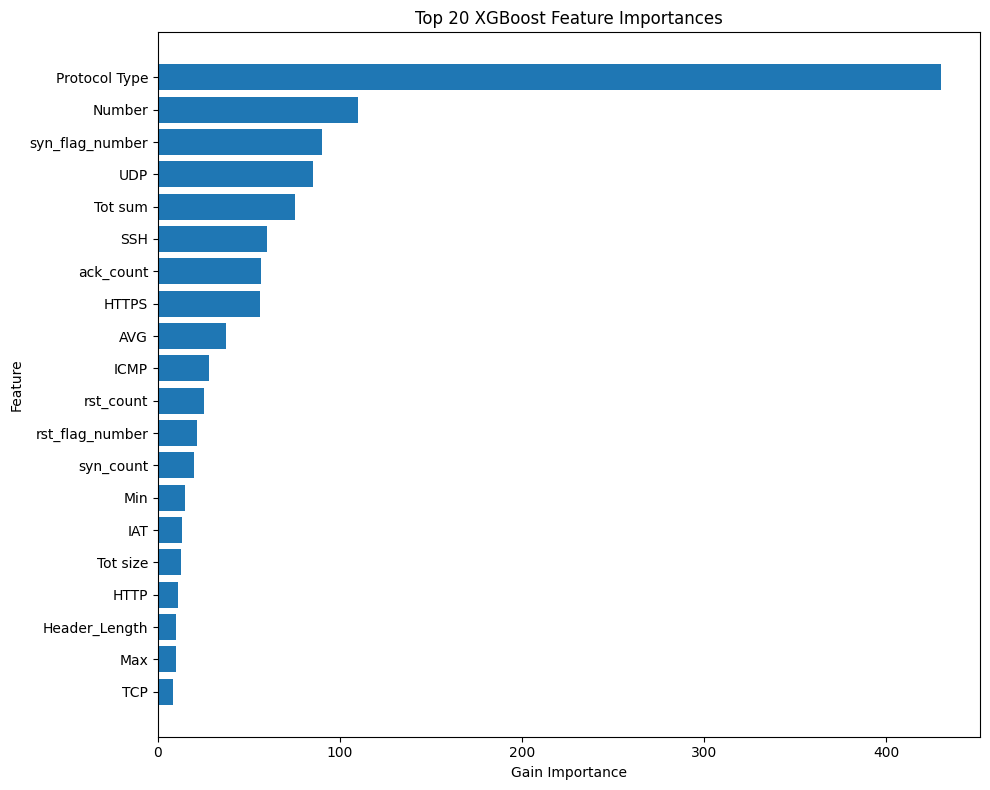

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

booster = model.get_booster()
score = booster.get_score(importance_type="gain")

if not score:
    raise RuntimeError("The model returned no feature importances.")

importance_df = pd.DataFrame({
    "feature": list(score.keys()),
    "gain": list(score.values()),
})

feature_map = {f"f{i}": col for i, col in enumerate(FEATURE_COLUMNS)}
importance_df["feature"] = importance_df["feature"].map(feature_map).fillna(importance_df["feature"])
importance_df = importance_df.sort_values("gain", ascending=False).reset_index(drop=True)

display(importance_df.head(20))

importance_path = MODEL_DIR / "xgb_8class_feature_importance_gain.csv"
importance_df.to_csv(importance_path, index=False)
print(f"Saved feature importance to {importance_path}")

top_k = importance_df.head(20).sort_values("gain")
plt.figure(figsize=(10, 8))
plt.barh(top_k["feature"], top_k["gain"])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

Saved validation per-class report to artifacts/models/xgb_8class_validation_per_class.csv
Classes sorted by holdout F1:


,label,precision,recall,f1,support
5,RECON,0.026421,0.360221,0.049231,661108
7,WEB,0.030020,0.730187,0.057670,23798
1,BRUTEFORCE,0.131494,0.601501,0.215810,12522
3,DOS,0.380097,0.412512,0.395642,7746340
6,SPOOFING,0.678706,0.334948,0.448538,465914
2,DDOS,0.873116,0.622407,0.726747,32535697
0,BENIGN,0.804391,0.783385,0.793749,1051313
4,MIRAI,0.993211,0.990483,0.991845,2521551


Classes sorted by holdout support:


,label,precision,recall,f1,support
1,BRUTEFORCE,0.131494,0.601501,0.215810,12522
7,WEB,0.030020,0.730187,0.057670,23798
6,SPOOFING,0.678706,0.334948,0.448538,465914
5,RECON,0.026421,0.360221,0.049231,661108
0,BENIGN,0.804391,0.783385,0.793749,1051313
4,MIRAI,0.993211,0.990483,0.991845,2521551
3,DOS,0.380097,0.412512,0.395642,7746340
2,DDOS,0.873116,0.622407,0.726747,32535697


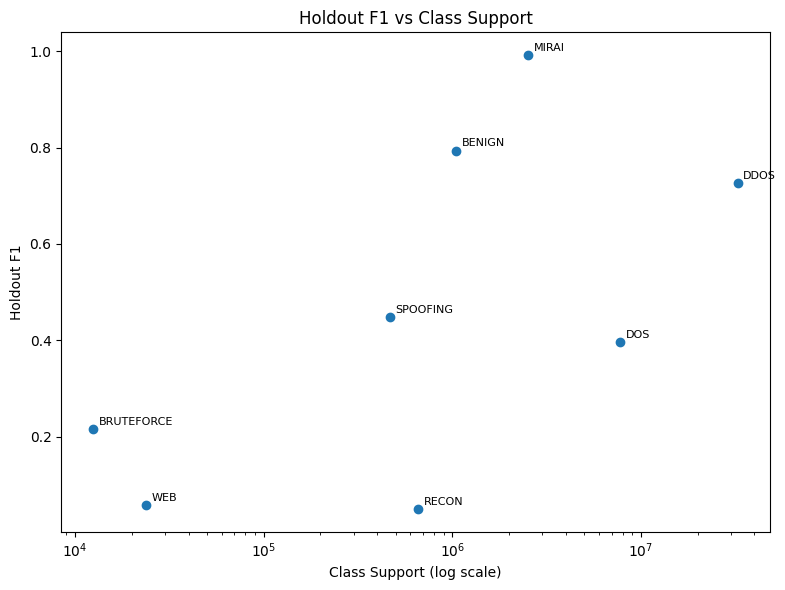

Validation vs holdout per-class comparison:


,label,precision_val,recall_val,f1_val,support_val,precision_test,recall_test,f1_test,support_test,f1_gap
5,RECON,0.826662,0.863200,0.844536,10000.0,0.026421,0.360221,0.049231,661108,0.795304
7,WEB,0.718096,0.628876,0.670531,4966.0,0.030020,0.730187,0.057670,23798,0.612862
3,DOS,0.999400,0.999000,0.999200,10000.0,0.380097,0.412512,0.395642,7746340,0.603558
1,BRUTEFORCE,0.807357,0.495599,0.614181,2613.0,0.131494,0.601501,0.215810,12522,0.398370
6,SPOOFING,0.895191,0.778100,0.832549,10000.0,0.678706,0.334948,0.448538,465914,0.384010
2,DDOS,0.999300,0.999400,0.999350,10000.0,0.873116,0.622407,0.726747,32535697,0.272603
4,MIRAI,0.999700,0.999800,0.999750,10000.0,0.993211,0.990483,0.991845,2521551,0.007905
0,BENIGN,0.709220,0.886100,0.787855,10000.0,0.804391,0.783385,0.793749,1051313,-0.005895


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

validation_report_path = MODEL_DIR / "xgb_8class_validation_per_class.csv"
test_report_path = MODEL_DIR / "xgb_8class_test_per_class.csv"

if "report_df" in globals():
    val_df = report_df.copy()
else:
    raise RuntimeError("report_df is not available in the current notebook state.")

if "label" not in val_df.columns:
    val_df = val_df.reset_index().rename(columns={"index": "label"})

if "f1-score" in val_df.columns and "f1" not in val_df.columns:
    val_df = val_df.rename(columns={"f1-score": "f1"})

if "support" not in val_df.columns:
    raise RuntimeError("Validation report is missing a support column.")

val_df = val_df[val_df["label"].isin(class_names)].copy()
val_df = val_df[["label", "precision", "recall", "f1", "support"]]
val_df.to_csv(validation_report_path, index=False)

print(f"Saved validation per-class report to {validation_report_path}")

# Holdout per-class report is already saved; load it so the notebook can be rerun from disk.
test_df = pd.read_csv(test_report_path)
if "f1-score" in test_df.columns and "f1" not in test_df.columns:
    test_df = test_df.rename(columns={"f1-score": "f1"})

test_df = test_df[test_df["label"].isin(class_names)].copy()
test_df = test_df[["label", "precision", "recall", "f1", "support"]]

print("Classes sorted by holdout F1:")
display(test_df.sort_values("f1"))

print("Classes sorted by holdout support:")
display(test_df.sort_values("support"))

plt.figure(figsize=(8, 6))
plt.scatter(test_df["support"], test_df["f1"])

for _, row in test_df.iterrows():
    plt.annotate(str(row["label"]), (row["support"], row["f1"]), fontsize=8, xytext=(4, 3), textcoords="offset points")

plt.xscale("log")
plt.xlabel("Class Support (log scale)")
plt.ylabel("Holdout F1")
plt.title("Holdout F1 vs Class Support")
plt.tight_layout()
plt.show()

compare_df = val_df.merge(
    test_df,
    on="label",
    suffixes=("_val", "_test"),
)
compare_df["f1_gap"] = compare_df["f1_val"] - compare_df["f1_test"]
compare_df = compare_df.sort_values("f1_gap", ascending=False)

print("Validation vs holdout per-class comparison:")
display(compare_df)


In [16]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight
import joblib

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
weighted_model = clone(model)
weighted_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

weighted_val_pred = weighted_model.predict(X_val).astype(np.int32)
weighted_val_acc = accuracy_score(y_val, weighted_val_pred)
weighted_val_macro_f1 = f1_score(y_val, weighted_val_pred, average="macro")
weighted_val_weighted_f1 = f1_score(y_val, weighted_val_pred, average="weighted")

weighted_report_df = pd.DataFrame(
    classification_report(
        y_val,
        weighted_val_pred,
        target_names=class_names,
        output_dict=True,
    )
).transpose()

weighted_report_path = MODEL_DIR / "xgb_8class_weighted_validation_per_class.csv"
weighted_model_path = MODEL_DIR / "xgb_8class_weighted.joblib"
weighted_report_df.to_csv(weighted_report_path)
joblib.dump(weighted_model, weighted_model_path)

print("Weighted validation accuracy:", weighted_val_acc)
print("Weighted validation macro F1:", weighted_val_macro_f1)
print("Weighted validation weighted F1:", weighted_val_weighted_f1)
print(f"Saved weighted validation report to {weighted_report_path}")
print(f"Saved weighted model to {weighted_model_path}")

display(weighted_report_df)


[0]	validation_0-mlogloss:1.93730


/home/jacob/workspace/csusb/cic_iot_2023_analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:51:13] WARNING: /workspace/src/context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
/home/jacob/workspace/csusb/cic_iot_2023_analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:51:13] WARNING: /workspace/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


[50]	validation_0-mlogloss:0.51484
[100]	validation_0-mlogloss:0.39612
[150]	validation_0-mlogloss:0.36951
[200]	validation_0-mlogloss:0.35592
[250]	validation_0-mlogloss:0.34762
[300]	validation_0-mlogloss:0.34193
[350]	validation_0-mlogloss:0.33769
[400]	validation_0-mlogloss:0.33442
[450]	validation_0-mlogloss:0.33179
[500]	validation_0-mlogloss:0.32949
[550]	validation_0-mlogloss:0.32750
[599]	validation_0-mlogloss:0.32600
Weighted validation accuracy: 0.8785717456606342
Weighted validation macro F1: 0.8403881221054055
Weighted validation weighted F1: 0.8803295173848614
Saved weighted validation report to artifacts/models/xgb_8class_weighted_validation_per_class.csv
Saved weighted model to artifacts/models/xgb_8class_weighted.joblib


,precision,recall,f1-score,support
BENIGN,0.737615,0.844200,0.787316,10000.000000
BRUTEFORCE,0.557593,0.616915,0.585756,2613.000000
DDOS,0.999300,0.999400,0.999350,10000.000000
DOS,0.999500,0.999100,0.999300,10000.000000
MIRAI,0.999700,0.999800,0.999750,10000.000000
RECON,0.881054,0.805900,0.841803,10000.000000
SPOOFING,0.904818,0.770000,0.831983,10000.000000
WEB,0.640122,0.720298,0.677847,4966.000000
accuracy,0.878572,0.878572,0.878572,0.878572
macro avg,0.839963,0.844452,0.840388,67579.000000


In [17]:
weighted_cm = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
weighted_dropped_missing = 0
weighted_seen_rows = 0

for chunk in iter_test_chunks(test_files, FEATURE_COLUMNS, chunksize=250_000):
    valid = chunk[TARGET_COL].notna() & chunk[TARGET_COL].isin(class_names)
    weighted_dropped_missing += (~valid).sum()

    chunk = chunk.loc[valid].copy()
    if len(chunk) == 0:
        continue

    X_chunk = chunk[FEATURE_COLUMNS].astype("float32")
    y_true = chunk[TARGET_COL].map(label_to_id).to_numpy(dtype=np.int32)
    y_pred = weighted_model.predict(X_chunk).astype(np.int32)

    np.add.at(weighted_cm, (y_true, y_pred), 1)
    weighted_seen_rows += len(chunk)

print("Weighted model evaluated test rows:", weighted_seen_rows)
print("Weighted model dropped unlabeled/invalid test rows:", weighted_dropped_missing)

weighted_test_acc, weighted_test_macro_f1, weighted_test_weighted_f1, weighted_test_per_class = metrics_from_confusion_matrix(weighted_cm)

print("Weighted test accuracy:", weighted_test_acc)
print("Weighted test macro F1:", weighted_test_macro_f1)
print("Weighted test weighted F1:", weighted_test_weighted_f1)

test_report_baseline = pd.read_csv(test_report_path)
if "f1-score" in test_report_baseline.columns and "f1" not in test_report_baseline.columns:
    test_report_baseline = test_report_baseline.rename(columns={"f1-score": "f1"})

test_report_baseline = test_report_baseline[test_report_baseline["label"].isin(class_names)].copy()
weighted_test_report = weighted_test_per_class.copy()

weighted_test_report_path = MODEL_DIR / "xgb_8class_weighted_test_per_class.csv"
weighted_test_cm_path = MODEL_DIR / "xgb_8class_weighted_test_confusion_matrix.csv"
weighted_test_metrics_path = MODEL_DIR / "xgb_8class_weighted_test_metrics.json"

weighted_test_report.to_csv(weighted_test_report_path, index=False)
weighted_cm_df = pd.DataFrame(
    weighted_cm,
    index=[id_to_label[i] for i in range(len(class_names))],
    columns=[id_to_label[i] for i in range(len(class_names))],
)
weighted_cm_df.to_csv(weighted_test_cm_path)

weighted_test_metrics = {
    "test_accuracy": float(weighted_test_acc),
    "test_macro_f1": float(weighted_test_macro_f1),
    "test_weighted_f1": float(weighted_test_weighted_f1),
    "evaluated_test_rows": int(weighted_seen_rows),
    "dropped_unlabeled_or_invalid_rows": int(weighted_dropped_missing),
}
with open(weighted_test_metrics_path, "w") as f:
    json.dump(weighted_test_metrics, f, indent=2)

print(f"Saved weighted test report to {weighted_test_report_path}")
print(f"Saved weighted test confusion matrix to {weighted_test_cm_path}")
print(f"Saved weighted test metrics to {weighted_test_metrics_path}")

weighted_compare = test_report_baseline.merge(
    weighted_test_report,
    on="label",
    suffixes=("_baseline", "_weighted"),
)
weighted_compare["f1_delta"] = weighted_compare["f1_weighted"] - weighted_compare["f1_baseline"]
weighted_compare = weighted_compare.sort_values("f1_delta", ascending=False)

print("Baseline vs weighted holdout per-class comparison:")
display(weighted_compare)


Weighted model evaluated test rows: 45018243
Weighted model dropped unlabeled/invalid test rows: 0
Weighted test accuracy: 0.5994283695167757
Weighted test macro F1: 0.4422603089316339
Weighted test weighted F1: 0.670751439027684
Saved weighted test report to artifacts/models/xgb_8class_weighted_test_per_class.csv
Saved weighted test confusion matrix to artifacts/models/xgb_8class_weighted_test_confusion_matrix.csv
Saved weighted test metrics to artifacts/models/xgb_8class_weighted_test_metrics.json
Baseline vs weighted holdout per-class comparison:


,label,precision_baseline,recall_baseline,f1_baseline,support_baseline,precision_weighted,recall_weighted,f1_weighted,support_weighted,f1_delta
4,MIRAI,0.993211,0.990483,0.991845,2521551,0.995631,0.992038,0.993831,2521551,0.001986
3,DOS,0.380097,0.412512,0.395642,7746340,0.378436,0.413019,0.394972,7746340,-0.000669
7,WEB,0.030020,0.730187,0.057670,23798,0.028914,0.830322,0.055882,23798,-0.001788
2,DDOS,0.873116,0.622407,0.726747,32535697,0.874611,0.618631,0.724680,32535697,-0.002067
0,BENIGN,0.804391,0.783385,0.793749,1051313,0.848774,0.739039,0.790114,1051313,-0.003635
5,RECON,0.026421,0.360221,0.049231,661108,0.022875,0.313533,0.042639,661108,-0.006592
6,SPOOFING,0.678706,0.334948,0.448538,465914,0.617461,0.306170,0.409359,465914,-0.039180
1,BRUTEFORCE,0.131494,0.601501,0.215810,12522,0.068688,0.807299,0.126605,12522,-0.089206


### Cell 12 -- visual dashboards (confusion matrices and class metrics)

This cell generates visual artifacts so results are easier to review than raw CSV files.

It keeps the CSV workflow unchanged and only adds plots + PNG outputs.

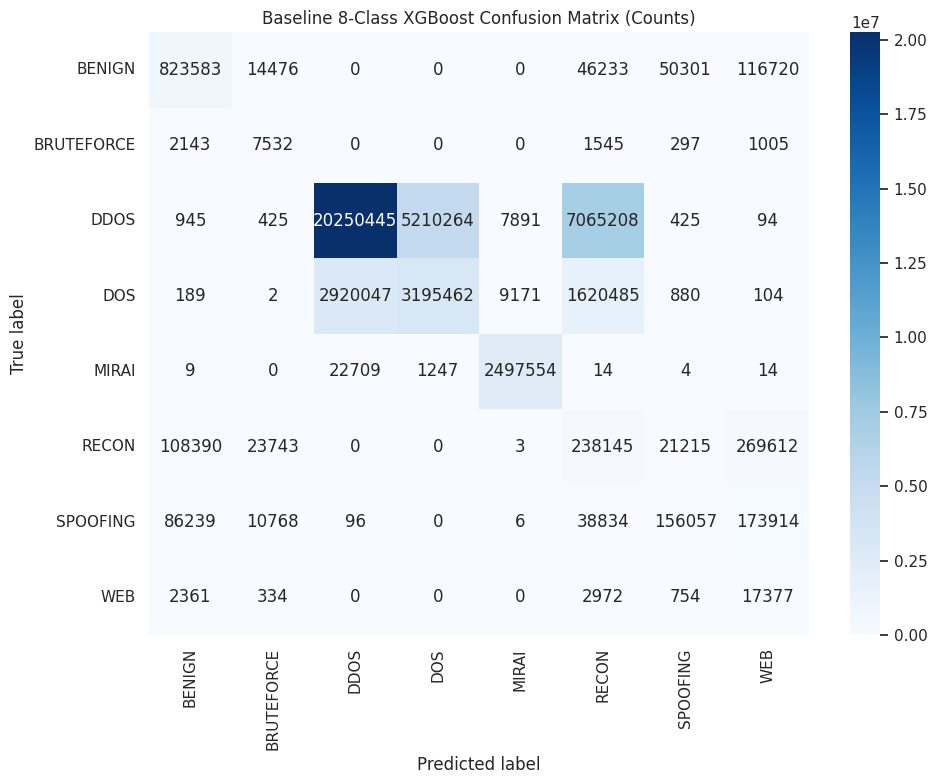

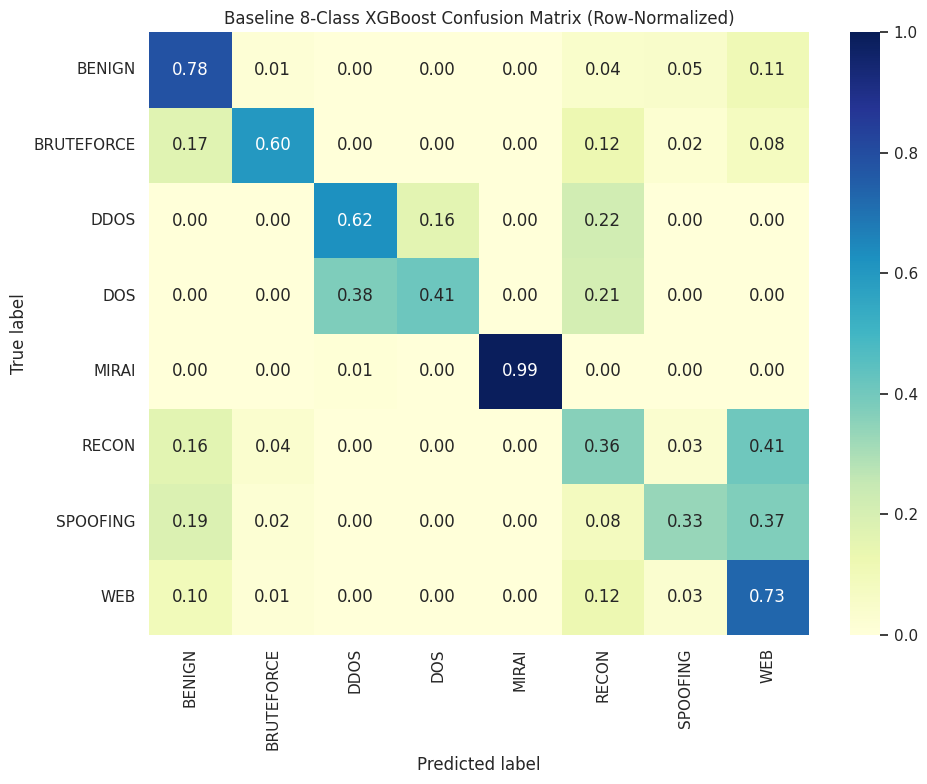

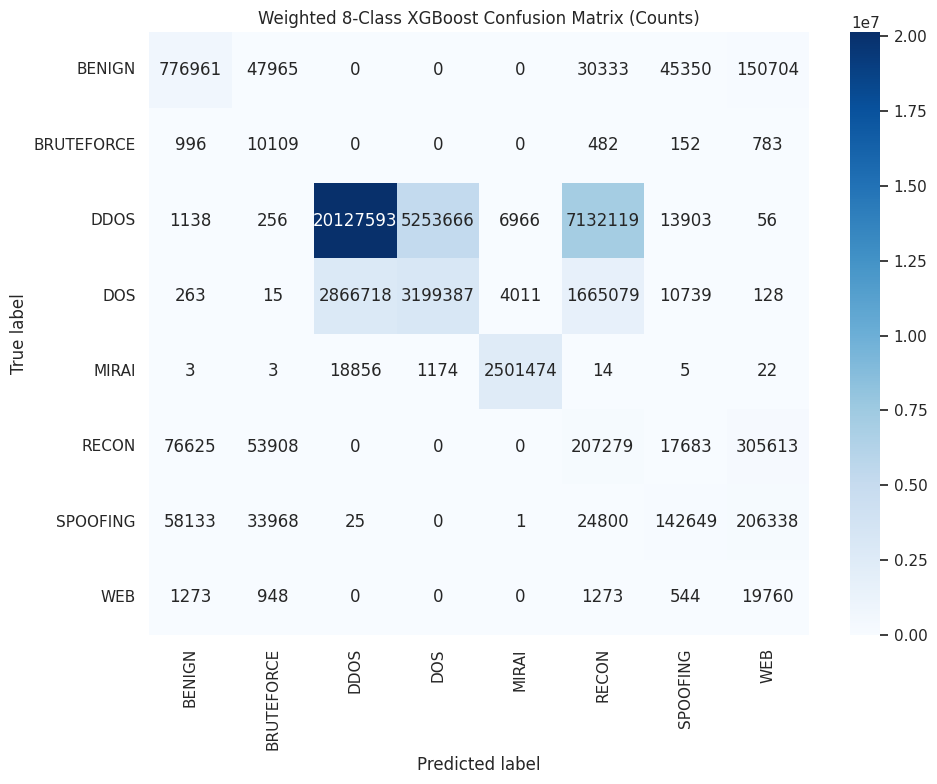

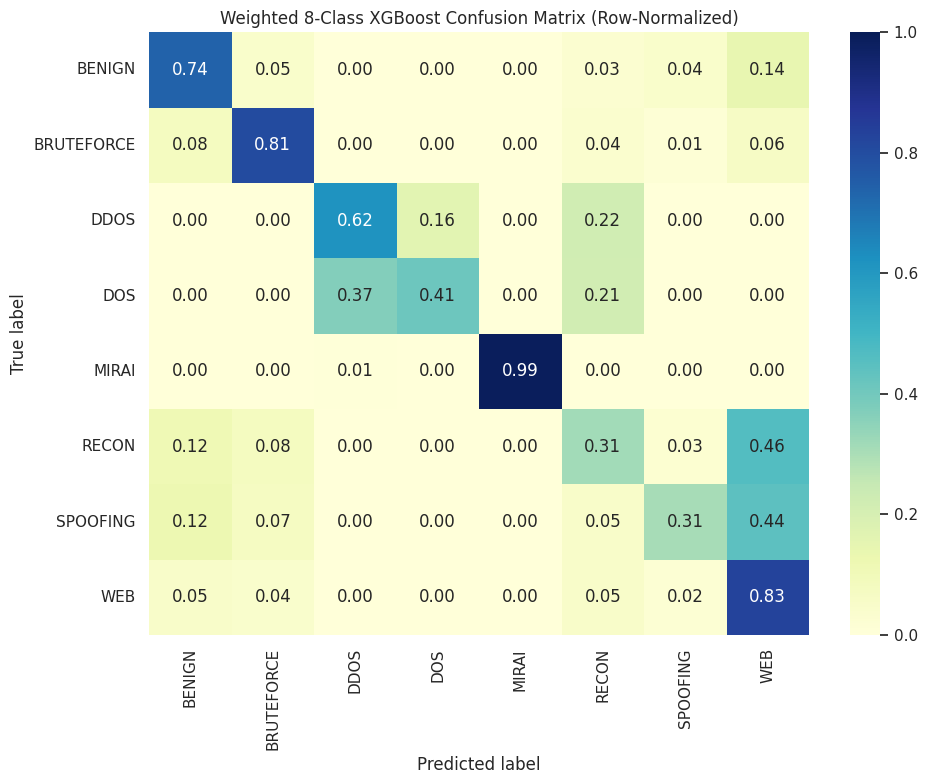

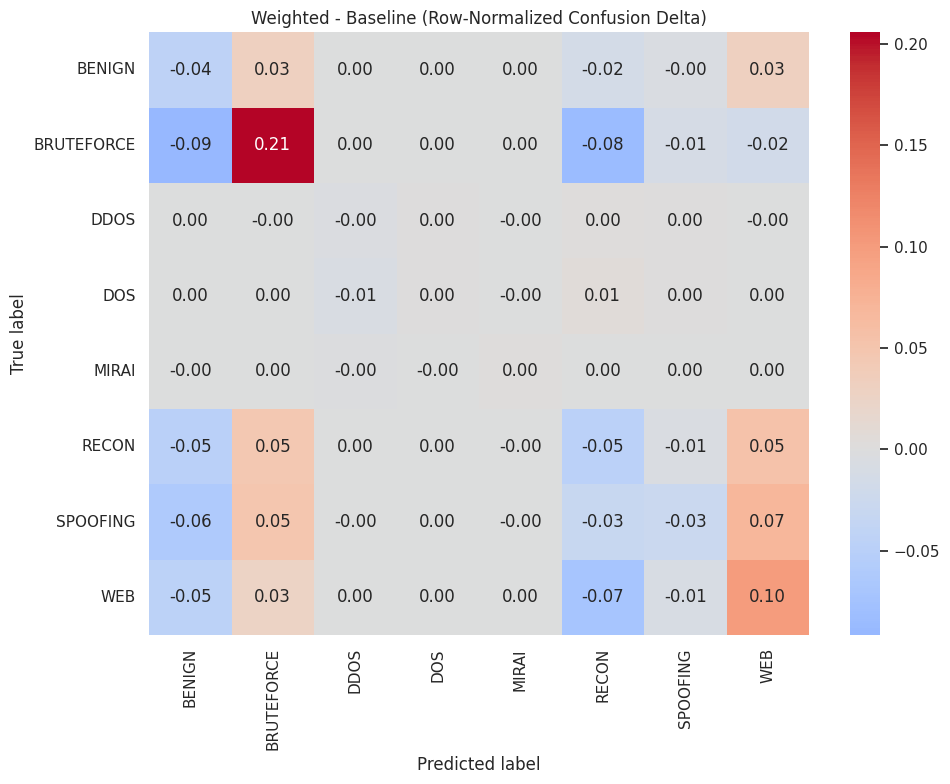

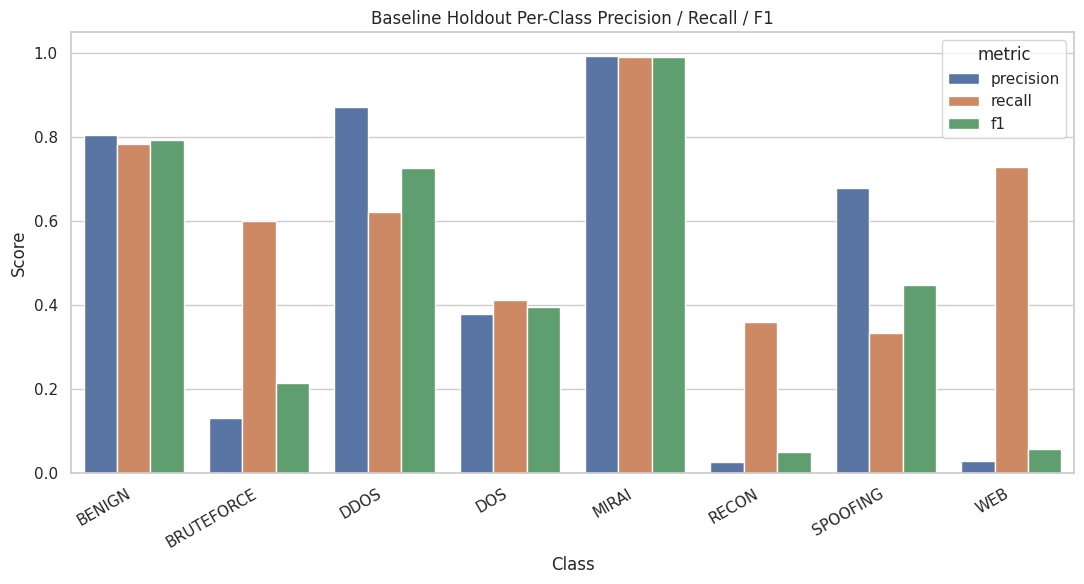

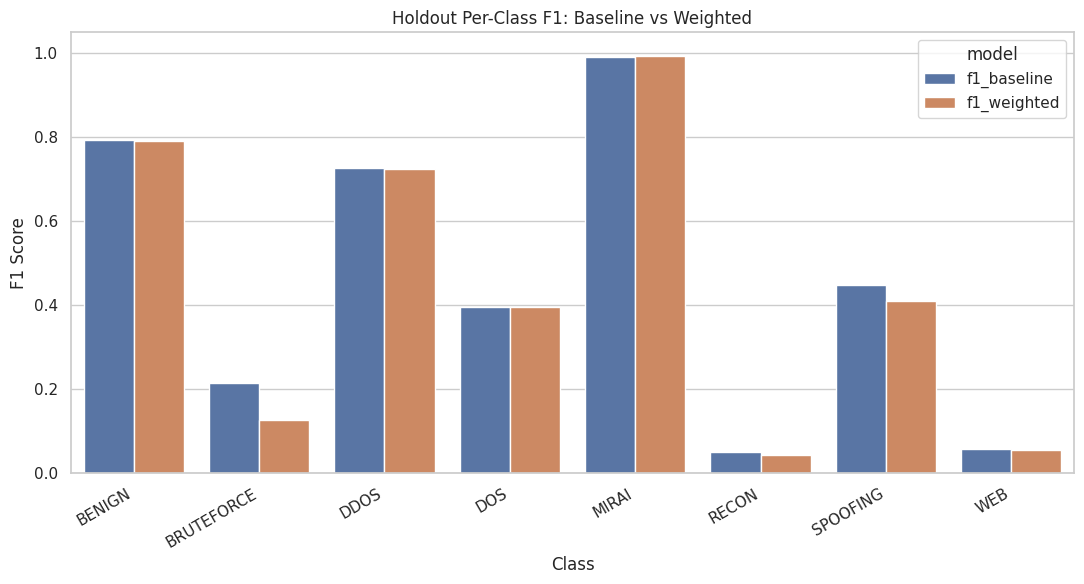

Saved visual artifacts:
- artifacts/models/xgb_8class_baseline_test_confusion_matrix_counts_heatmap.png
- artifacts/models/xgb_8class_baseline_test_confusion_matrix_row_normalized_heatmap.png
- artifacts/models/xgb_8class_weighted_test_confusion_matrix_counts_heatmap.png
- artifacts/models/xgb_8class_weighted_test_confusion_matrix_row_normalized_heatmap.png
- artifacts/models/xgb_8class_weighted_minus_baseline_row_norm_delta_heatmap.png
- artifacts/models/xgb_8class_baseline_test_per_class_prf_bars.png
- artifacts/models/xgb_8class_holdout_f1_baseline_vs_weighted.png


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

labels = [id_to_label[i] for i in range(len(class_names))]

baseline_cm_path = MODEL_DIR / "xgb_8class_test_confusion_matrix.csv"
weighted_cm_path = MODEL_DIR / "xgb_8class_weighted_test_confusion_matrix.csv"

baseline_per_class_path = MODEL_DIR / "xgb_8class_test_per_class.csv"
weighted_per_class_path = MODEL_DIR / "xgb_8class_weighted_test_per_class.csv"


def load_cm(cm_var_name, fallback_path):
    if cm_var_name in globals() and isinstance(globals()[cm_var_name], np.ndarray):
        return globals()[cm_var_name]
    cm_df_local = pd.read_csv(fallback_path, index_col=0)
    return cm_df_local.to_numpy(dtype=np.int64)


def row_normalize(matrix):
    row_sums = matrix.sum(axis=1, keepdims=True)
    return np.divide(matrix, row_sums, out=np.zeros_like(matrix, dtype=float), where=row_sums != 0)


def plot_confusion_views(matrix, labels_list, title_prefix, file_prefix):
    cm_df_local = pd.DataFrame(matrix, index=labels_list, columns=labels_list)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df_local, annot=True, fmt=".0f", cmap="Blues", cbar=True)
    plt.title(f"{title_prefix} Confusion Matrix (Counts)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    counts_png = MODEL_DIR / f"{file_prefix}_counts_heatmap.png"
    plt.savefig(counts_png, dpi=200)
    plt.show()

    norm_matrix = row_normalize(matrix)
    norm_df = pd.DataFrame(norm_matrix, index=labels_list, columns=labels_list)

    plt.figure(figsize=(10, 8))
    sns.heatmap(norm_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0.0, vmax=1.0, cbar=True)
    plt.title(f"{title_prefix} Confusion Matrix (Row-Normalized)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    norm_png = MODEL_DIR / f"{file_prefix}_row_normalized_heatmap.png"
    plt.savefig(norm_png, dpi=200)
    plt.show()

    return norm_matrix, counts_png, norm_png


baseline_cm_local = load_cm("cm", baseline_cm_path)
baseline_norm, baseline_counts_png, baseline_norm_png = plot_confusion_views(
    baseline_cm_local,
    labels,
    "Baseline 8-Class XGBoost",
    "xgb_8class_baseline_test_confusion_matrix",
)

weighted_norm = None
if weighted_cm_path.exists() or "weighted_cm" in globals():
    weighted_cm_local = load_cm("weighted_cm", weighted_cm_path)
    weighted_norm, weighted_counts_png, weighted_norm_png = plot_confusion_views(
        weighted_cm_local,
        labels,
        "Weighted 8-Class XGBoost",
        "xgb_8class_weighted_test_confusion_matrix",
    )
else:
    print("Weighted confusion matrix not found in memory or on disk. Skipping weighted heatmaps.")

if weighted_norm is not None:
    norm_delta = weighted_norm - baseline_norm
    norm_delta_df = pd.DataFrame(norm_delta, index=labels, columns=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(norm_delta_df, annot=True, fmt=".2f", cmap="coolwarm", center=0.0, cbar=True)
    plt.title("Weighted - Baseline (Row-Normalized Confusion Delta)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    delta_png = MODEL_DIR / "xgb_8class_weighted_minus_baseline_row_norm_delta_heatmap.png"
    plt.savefig(delta_png, dpi=200)
    plt.show()
else:
    delta_png = None

baseline_per_class_df = test_per_class.copy() if "test_per_class" in globals() else pd.read_csv(baseline_per_class_path)
weighted_per_class_df = weighted_test_per_class.copy() if "weighted_test_per_class" in globals() else (
    pd.read_csv(weighted_per_class_path) if weighted_per_class_path.exists() else None
)

metric_long = baseline_per_class_df.melt(
    id_vars=["label", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=metric_long, x="label", y="score", hue="metric")
plt.ylim(0, 1.05)
plt.title("Baseline Holdout Per-Class Precision / Recall / F1")
plt.xlabel("Class")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
prf_png = MODEL_DIR / "xgb_8class_baseline_test_per_class_prf_bars.png"
plt.savefig(prf_png, dpi=200)
plt.show()

if weighted_per_class_df is not None:
    f1_compare = baseline_per_class_df[["label", "f1"]].merge(
        weighted_per_class_df[["label", "f1"]],
        on="label",
        suffixes=("_baseline", "_weighted"),
    )
    f1_compare_long = f1_compare.melt(
        id_vars=["label"],
        value_vars=["f1_baseline", "f1_weighted"],
        var_name="model",
        value_name="f1",
    )

    plt.figure(figsize=(11, 6))
    sns.barplot(data=f1_compare_long, x="label", y="f1", hue="model")
    plt.ylim(0, 1.05)
    plt.title("Holdout Per-Class F1: Baseline vs Weighted")
    plt.xlabel("Class")
    plt.ylabel("F1 Score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    f1_compare_png = MODEL_DIR / "xgb_8class_holdout_f1_baseline_vs_weighted.png"
    plt.savefig(f1_compare_png, dpi=200)
    plt.show()
else:
    f1_compare_png = None

print("Saved visual artifacts:")
print("-", baseline_counts_png)
print("-", baseline_norm_png)
if weighted_norm is not None:
    print("-", weighted_counts_png)
    print("-", weighted_norm_png)
if delta_png is not None:
    print("-", delta_png)
print("-", prf_png)
if f1_compare_png is not None:
    print("-", f1_compare_png)
